# 05 — April batch · Multiscale LRG

This notebook delivers the **multiscale Laplacian Renormalisation Group**
(LRG) analysis of the April 2026 fMRI batch. The percolation pass in
notebook `01` showed that even after MP cleaning these matrices give a
single sharp drop in $P_\infty(\theta)$ — no obvious modular threshold.
The LRG framework (Villegas–Gili–Caldarelli–Gabrielli, *Nat. Phys.*
**19**, 445 (2023); Villegas–Gabrielli–Poggialini–Gili, *Phys. Rev.
Research* **7**, 013065 (2025)) operates on the **Laplacian spectrum**
rather than on edge thresholds and can expose structure where
percolation cannot, *provided* the matrix is reduced to a non-negative
connected graph first.

### What the chain does, per matrix

1. **MP denoise** the signed correlation matrix using the per-variant
   $\gamma = N/T$ (this fixes the eigenvalue clipping so signal modes
   above $\lambda_+ = (1+\sqrt\gamma)^2$ are preserved while in-bulk
   noise modes are flattened to the support boundary).
2. **Sparsify to a non-negative connected backbone**. We run two
   methods in parallel:
   * `mp_validated` — reconstructs the matrix using only the eigenvalues
     **outside** the MP bulk; the canonical "signal only" projection.
   * `percolation` — keeps every edge above
     $\theta^\ast = \min_i \max_j w_{ij}$, the largest threshold that
     preserves a spanning graph (no nodes lost).
   Disparity α=0.05 is also implemented but **fails on dense
   correlation matrices**: with strengths $s_i \approx 30$ and edge
   weights $\approx 0.3$, $p_{ij} = w/s \approx 0.01$ never reaches the
   anomalous-strength tail, so the backbone collapses to either zero
   edges or the full graph. We document this and skip it.
3. **Multiscale LRG** on the backbone Laplacian:
   * Compute $S(\tau) = -\mathrm{Tr}\,\hat\rho_\tau \log \hat\rho_\tau$
     and specific heat $C(\tau) = -dS/d\log\tau$, where
     $\hat\rho_\tau = e^{-\tau L}/\mathrm{Tr}\, e^{-\tau L}$.
   * Identify $\tau' = 1/\lambda_{\max}$ (finest LRG scale) and
     $\tau^\ast = \arg\max_\tau C(\tau)$ (largest scale at which
     structure is resolved).
   * On a log-grid $\tau \in [\tau', 3\tau^\ast]$, build the
     communication-distance dendrogram
     $\mathcal{D}_{ij}(\tau) = (1-\delta_{ij})/\hat\rho_{ij}(\tau)$
     (this is an ultrametric distance), pick the optimal cut via
     $\arg\max_n \Psi(n;\tau)$ where
     $\Psi(n;\tau) = \mathcal{N}[\log_{10}\Delta_n - \log_{10}\Delta_{n+1}]$
     is the partition-stability index (paper Eq. 2).
4. **Cross-τ metastability**: nodes whose cluster-membership *set*
   changes along the τ-trajectory are flagged as bridges.

### Cross-contrast deliverable (§5)

For each processing variant, compare CO2 vs rest using three
complementary metric layers:

* **LRG-native, partition-free** — $C(\tau)$ overlay; $\Delta \tau^\ast$;
  integrated $|\Delta C|$ along $\log\tau$.
* **Per-τ partition similarity** — Reduced Mutual Information
  (Newman, Cantwell, Young, *Phys. Rev. E* **101**, 042304 (2020)),
  which handles partitions with different cluster counts correctly.
  Not ARI — ARI is degraded by the very granularity-changing behaviour
  that LRG is designed to expose.
* **Full-hierarchy similarity** — cophenetic correlation (Sokal–Rohlf)
  and Baker's γ between the two dendrograms at $\tau'$.


In [1]:
from collections import defaultdict
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from multifunbrain.analysis.lrg.compare import (
    bakers_gamma,
    cophenetic_correlation,
    reduced_mutual_information,
    specific_heat_comparison,
)
from multifunbrain.datasets.april import BANDS, CONTRASTS, PROCESSING_VARIANTS
from multifunbrain.pipeline.multiscale import MultiscaleResult
from multifunbrain.visualization.plotlib.lrg_multiscale_plots import (
    plot_dendrogram_with_psi,
    plot_metastable_overlay,
    plot_partition_flow,
    plot_psi_curve,
    plot_rmi_curve,
    plot_specific_heat,
    plot_specific_heat_overlay,
    plot_tanglegram,
)
from multifunbrain.visualization.plotlib.pipeline_plots import plot_results_grid

LRG_ROOT = Path('../../data/correlation_matrices_results/april')
GLOBAL_DIR = LRG_ROOT / 'lrg_global'
BANDS_DIR = LRG_ROOT / 'lrg_bands'
PATIENTS_DIR = LRG_ROOT / 'lrg_patients_sample'

BACKBONES = ['mp_validated', 'percolation']  # canonical, sensitivity


def load_one(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def load_all(root_dir, backbone):
    out = {}
    for path in (root_dir / backbone).rglob('*.pkl'):
        res = load_one(path)
        out[res.label] = res
    return out


# globals_by_backbone[backbone][(contrast, processing)] = MultiscaleResult
globals_by_backbone = {}
for bb in BACKBONES:
    raw = load_all(GLOBAL_DIR, bb)
    indexed = {}
    for label, res in raw.items():
        proc_tag = label.split('/')[-1]
        contrast, processing = proc_tag.split('_', 1)
        indexed[(contrast, processing)] = res
    globals_by_backbone[bb] = indexed

# Manifests for quick summaries
manifests = {
    'global': pd.read_csv(GLOBAL_DIR / 'manifest.csv'),
    'bands': pd.read_csv(BANDS_DIR / 'manifest.csv'),
    'patients': pd.read_csv(PATIENTS_DIR / 'manifest.csv'),
}

for name, mf in manifests.items():
    print(f"{name}: {len(mf)} runs, backbones={sorted(mf.backbone.unique())}, "
          f"n_alive median={mf.n_alive.median():.0f}, "
          f"τ* median={mf['tau_star'].median():.3g}")
print()
print('Loaded global results per backbone:',
      {bb: len(globals_by_backbone[bb]) for bb in BACKBONES})


global: 20 runs, backbones=['mp_validated', 'percolation'], n_alive median=100, τ* median=5.28
bands: 60 runs, backbones=['mp_validated', 'percolation'], n_alive median=100, τ* median=5.28
patients: 24 runs, backbones=['mp_validated', 'percolation'], n_alive median=100, τ* median=5.28

Loaded global results per backbone: {'mp_validated': 10, 'percolation': 10}


## 1 · Specific heat across globals

For each global aggregate, plot $C(\tau) = -dS/d\log\tau$ with both
characteristic scales marked. Peaks in $C(\tau)$ are the τ-locations at
which the LRG diffusion exposes coherent mesoscopic structure; on
**dense** matrices a single broad peak around $\tau \sim \tau^\ast$ is
typical, while genuinely modular networks show multiple narrower peaks.

We show the **mp_validated** backbone first (canonical) and the
**percolation** backbone second (sensitivity check). Visual agreement
between the two is the empirical guarantee that the result isn't an
artefact of one specific sparsifier.

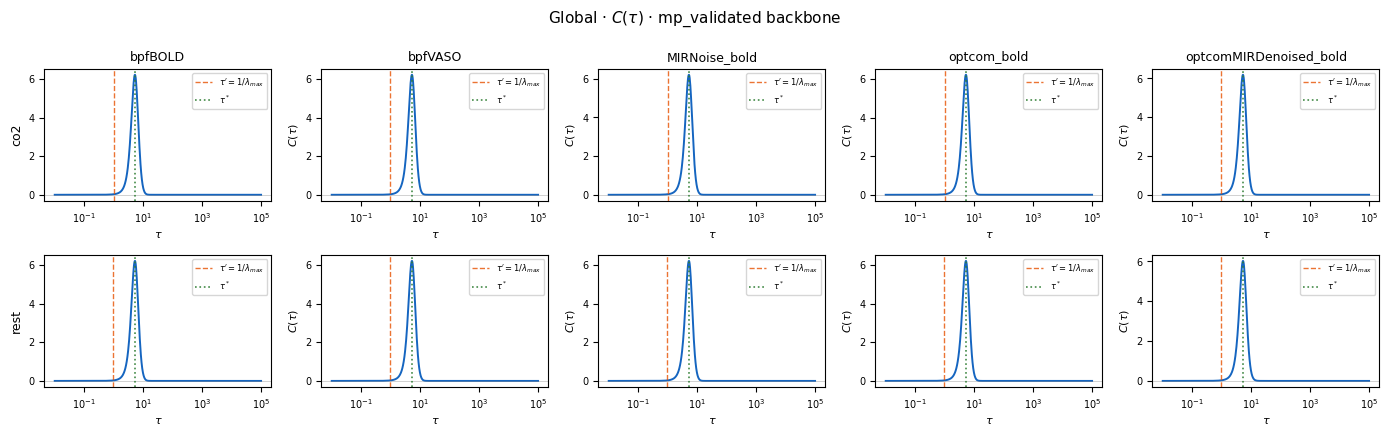

In [2]:
fig, _ = plot_results_grid(
    globals_by_backbone['mp_validated'],
    plot_specific_heat,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.8, 2.2),
    suptitle=r'Global · $C(\tau)$ · mp_validated backbone',
    mark_tau_prime=True,
    mark_tau_star=True,
)
plt.show()


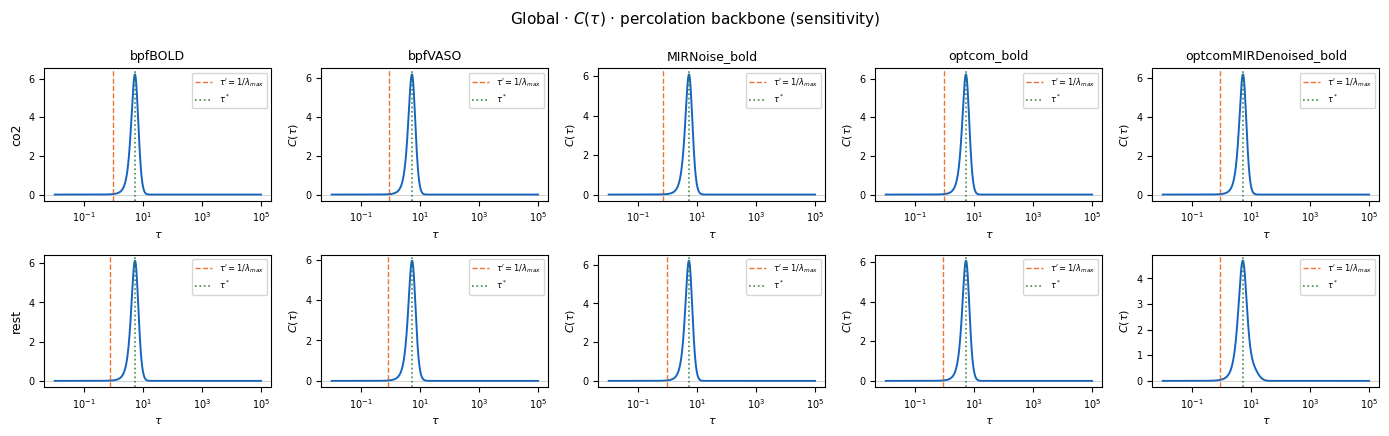

In [3]:
fig, _ = plot_results_grid(
    globals_by_backbone['percolation'],
    plot_specific_heat,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.8, 2.2),
    suptitle=r'Global · $C(\tau)$ · percolation backbone (sensitivity)',
    mark_tau_prime=True,
    mark_tau_star=True,
)
plt.show()


## 2 · Dendrograms at $\tau' = 1/\lambda_{\max}$ + $\Psi(n;\tau')$

At the finest LRG scale $\tau' = 1/\lambda_{\max}$ each backbone yields
one dendrogram with the partition-stability optimum $n^\ast(\tau')$
marked in red. The grid below shows the dendrogram per (contrast,
processing) for the **mp_validated** backbone (single-scale view).


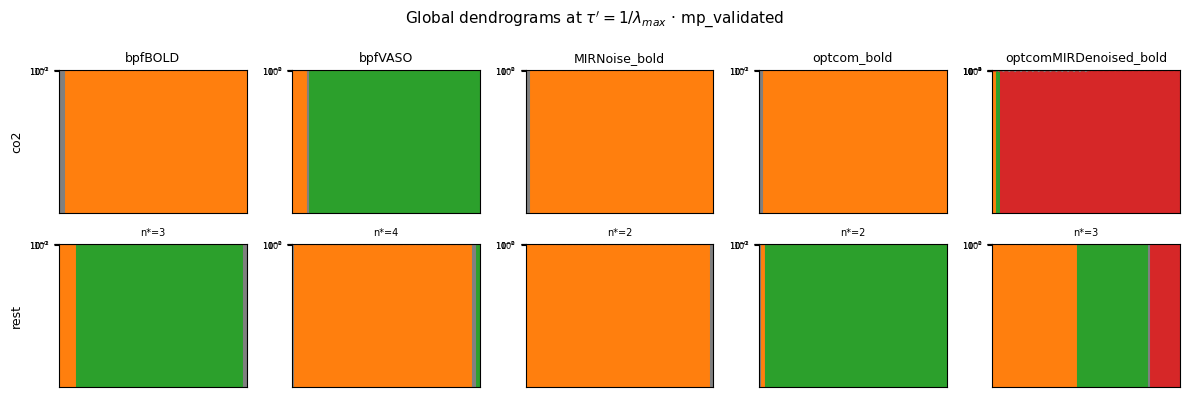

In [4]:
def _plot_dendro_at_prime(result, *, ax=None, **kwargs):
    # Wrapper so plot_results_grid can call a single-axis helper that
    # draws just the dendrogram (no Ψ subpanel) at τ'.
    from scipy.cluster.hierarchy import dendrogram
    if not result.per_tau:
        if ax is None:
            fig, ax = plt.subplots()
        else:
            fig = ax.get_figure()
        ax.text(0.5, 0.5, result.error or 'no data',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_axis_off()
        return fig, ax
    # nearest τ' entry
    idx = int(np.argmin(np.abs(result.tau_grid - result.tau_prime)))
    entry = result.per_tau[idx]
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 2.5))
    else:
        fig = ax.get_figure()
    dendrogram(entry['linkage'], ax=ax,
               color_threshold=entry['flat_threshold'],
               above_threshold_color='grey', no_labels=True)
    ax.axhline(entry['flat_threshold'], color='#C62828',
               linewidth=0.8, linestyle='--', alpha=0.8)
    ax.set_yscale('log')
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(f"n*={entry['n_clusters']}", fontsize=7)
    return fig, ax


fig, _ = plot_results_grid(
    globals_by_backbone['mp_validated'],
    _plot_dendro_at_prime,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.4, 2.0),
    suptitle=r"Global dendrograms at $\tau' = 1/\lambda_{max}$ · mp_validated",
)
plt.show()


## 3 · Single-scale view — $\Psi(n; \tau')$ in detail

For one representative global panel (`co2/bpfBOLD`) we now zoom in on
the partition-stability curve $\Psi(n;\tau')$ across $n$. The red line
marks the global maximum (the optimal cut); secondary peaks would
indicate multiple mesoscopic scales living in the same dendrogram.


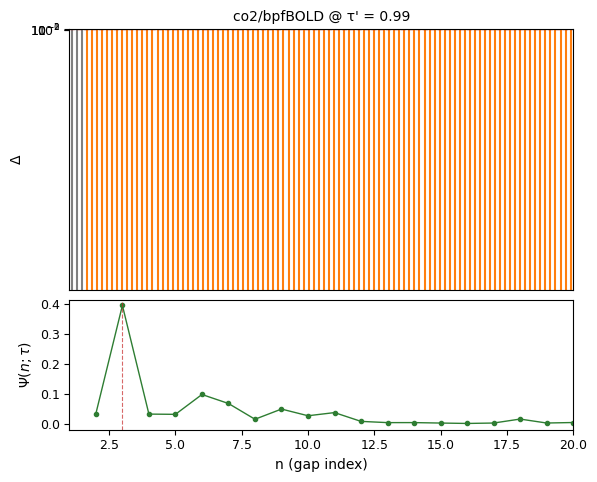

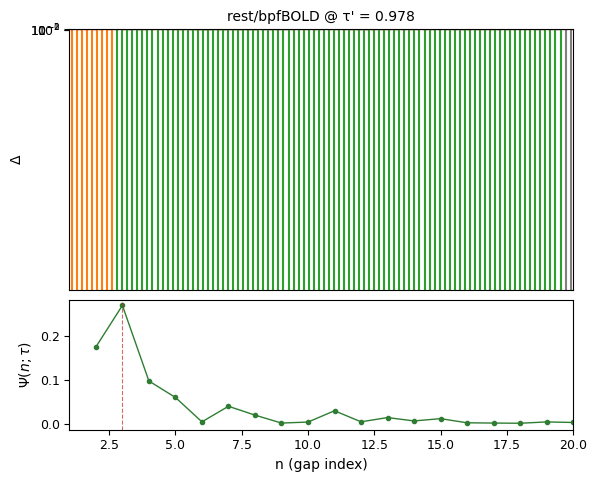

In [5]:
focus_key = ('co2', 'bpfBOLD')
res_a = globals_by_backbone['mp_validated'][focus_key]
res_b = globals_by_backbone['mp_validated'][('rest', 'bpfBOLD')]

fig, axes = plt.subplots(2, 1, figsize=(6.5, 5.2),
                         gridspec_kw={'height_ratios': [3, 1.5], 'hspace': 0.05})
plot_dendrogram_with_psi(
    res_a, ax_top=axes[0], ax_bot=axes[1],
    title=f"co2/bpfBOLD @ τ' = {res_a.tau_prime:.3g}",
    compact=False,
)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(6.5, 5.2),
                         gridspec_kw={'height_ratios': [3, 1.5], 'hspace': 0.05})
plot_dendrogram_with_psi(
    res_b, ax_top=axes[0], ax_bot=axes[1],
    title=f"rest/bpfBOLD @ τ' = {res_b.tau_prime:.3g}",
    compact=False,
)
plt.show()


## 4 · Multiscale view — partition flow across τ

Each row is a brain ROI, each column a τ-step. Colour = cluster label
at that τ (palette `tab20`). Rows with frequent colour changes are
**metastable nodes**: they swap modules at specific τ values and act as
bridges between mesoscopic communities. Stable cores show solid
horizontal bands.


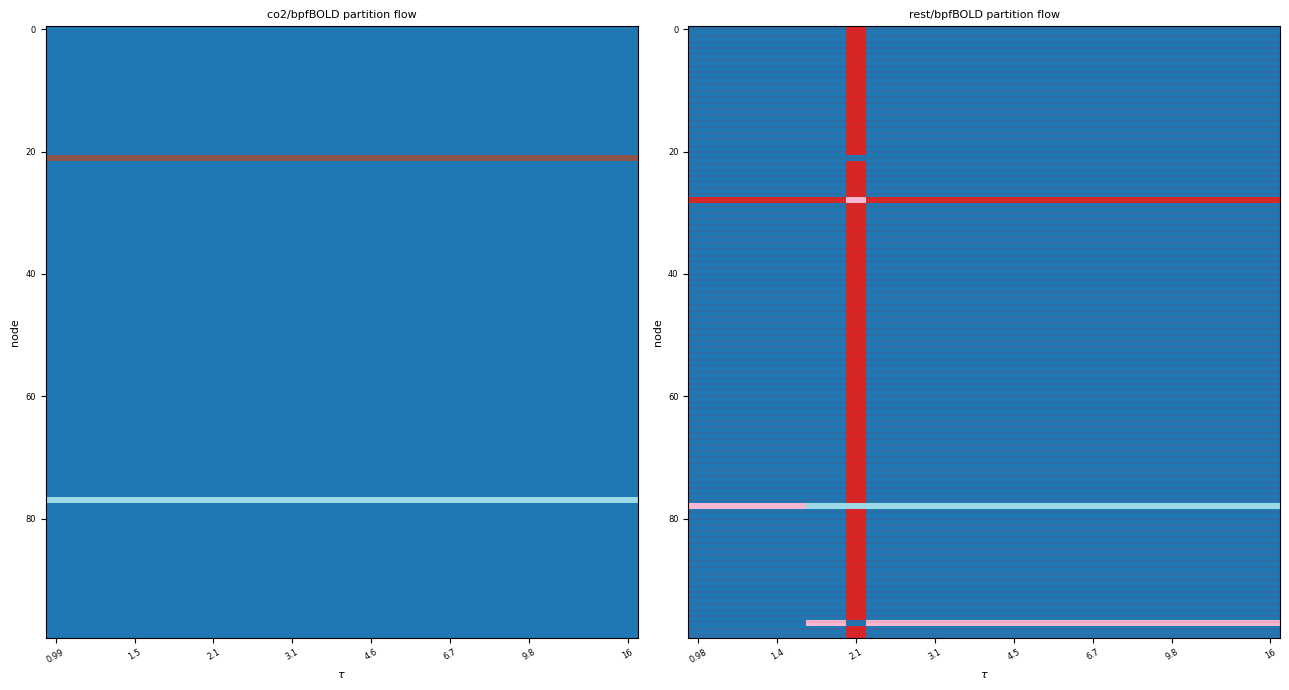

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
plot_partition_flow(res_a, ax=axes[0], title='co2/bpfBOLD partition flow')
plot_partition_flow(res_b, ax=axes[1], title='rest/bpfBOLD partition flow')
plt.tight_layout()
plt.show()


## 5 · Cross-contrast comparison — CO2 vs rest

Three independent angles on each (CO2 vs rest) pair within each
processing variant. If the diffusion timescale and/or modular structure
genuinely differ between hypercapnia and resting state, **all three
diagnostics should move together** — that's the multi-metric robustness
check.


### 5.1 LRG-native — $C(\tau)$ overlay

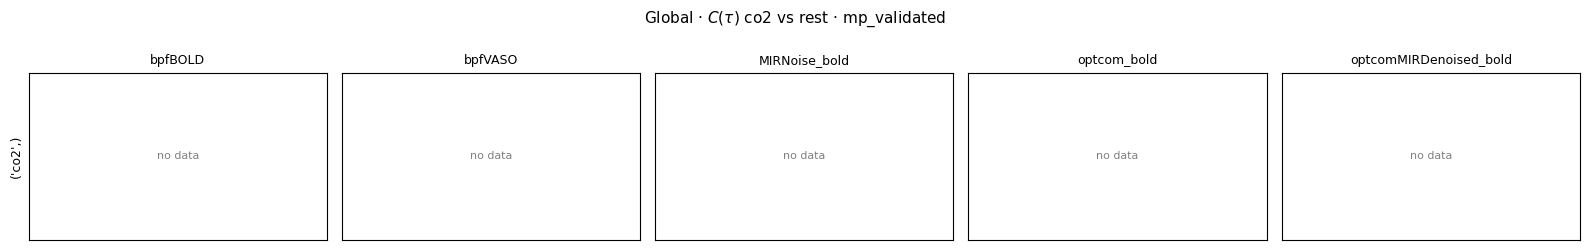

In [7]:
def _plot_overlay(result_co2, *, ax=None, **kwargs):
    # Pair lookup uses the closure-local `globals_by_backbone` dict
    # to find the matching rest result for the same processing.
    contrast, processing = None, None
    # Recover processing from result.label
    proc_tag = result_co2.label.split('/')[-1]
    contrast, processing = proc_tag.split('_', 1)
    if contrast != 'co2':
        return result_co2  # caller picked the wrong row
    backbone = kwargs.pop('_backbone', 'mp_validated')
    rest_res = globals_by_backbone[backbone][('rest', processing)]
    return plot_specific_heat_overlay(
        result_co2, rest_res, ax=ax,
        labels=('co2', 'rest'), title=processing, **kwargs,
    )


co2_only = {('co2', p): r for (c, p), r in globals_by_backbone['mp_validated'].items() if c == 'co2'}
fig, _ = plot_results_grid(
    co2_only,
    _plot_overlay,
    row_keys=[('co2',)],
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(3.2, 2.5),
    suptitle=r"Global · $C(\tau)$ co2 vs rest · mp_validated",
    _backbone='mp_validated',
)
plt.show()


### 5.2 Per-τ partition similarity — Reduced Mutual Information

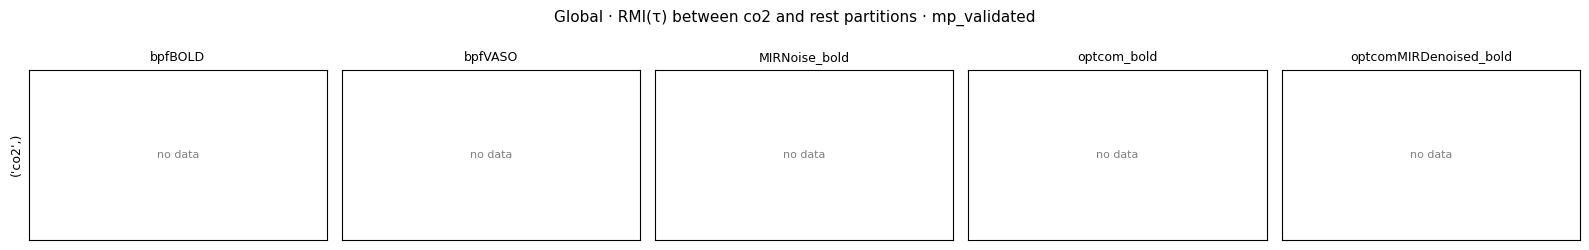

In [8]:
def _plot_rmi(result_co2, *, ax=None, **kwargs):
    proc_tag = result_co2.label.split('/')[-1]
    contrast, processing = proc_tag.split('_', 1)
    backbone = kwargs.pop('_backbone', 'mp_validated')
    rest_res = globals_by_backbone[backbone][('rest', processing)]
    return plot_rmi_curve(
        result_co2, rest_res, ax=ax,
        labels=('co2', 'rest'),
        title=processing, **kwargs,
    )


fig, _ = plot_results_grid(
    co2_only,
    _plot_rmi,
    row_keys=[('co2',)],
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(3.2, 2.5),
    suptitle='Global · RMI(τ) between co2 and rest partitions · mp_validated',
    _backbone='mp_validated',
)
plt.show()


### 5.3 Full-hierarchy similarity — cophenetic + Baker's γ + metastable Jaccard

In [9]:
def _at_tau_prime(result):
    idx = int(np.argmin(np.abs(result.tau_grid - result.tau_prime)))
    return result.per_tau[idx]


def _hier_metrics(res_a, res_b):
    entry_a = _at_tau_prime(res_a)
    entry_b = _at_tau_prime(res_b)
    coph = float('nan')
    baker = float('nan')
    if entry_a['linkage'].shape == entry_b['linkage'].shape:
        coph = cophenetic_correlation(entry_a['linkage'], entry_b['linkage'])
        baker = bakers_gamma(entry_a['linkage'], entry_b['linkage'])
    meta_a = set(res_a.metastable.keys())
    meta_b = set(res_b.metastable.keys())
    jacc = (len(meta_a & meta_b) / len(meta_a | meta_b)) if (meta_a | meta_b) else float('nan')
    cmp = specific_heat_comparison(
        res_a.specific_heat, res_b.specific_heat, res_a.time_grid_broad
    )
    return {
        'cophenetic_r': coph,
        'bakers_gamma': baker,
        'metastable_jaccard': jacc,
        'delta_log_tau_star': cmp['log_delta_tau_star'],
        'area_abs_dC': cmp['area_abs_delta'],
    }


rows = []
for backbone in BACKBONES:
    for processing in PROCESSING_VARIANTS:
        try:
            co2 = globals_by_backbone[backbone][('co2', processing)]
            rest = globals_by_backbone[backbone][('rest', processing)]
        except KeyError:
            continue
        m = _hier_metrics(co2, rest)
        m['backbone'] = backbone
        m['processing'] = processing
        rows.append(m)
hierarchy_metrics = pd.DataFrame(rows)[
    ['backbone', 'processing', 'cophenetic_r', 'bakers_gamma',
     'metastable_jaccard', 'delta_log_tau_star', 'area_abs_dC']
]
print(hierarchy_metrics.to_string(index=False, float_format='{:.3f}'.format))


    backbone             processing  cophenetic_r  bakers_gamma  metastable_jaccard  delta_log_tau_star  area_abs_dC
mp_validated                bpfBOLD         0.396         0.294               0.000               0.000        0.004
mp_validated                bpfVASO         0.236         0.524               0.980               0.000        0.004
mp_validated          MIRNoise_bold           NaN           NaN               0.000               0.000        0.012
mp_validated            optcom_bold         0.183         0.023               0.000               0.000        0.004
mp_validated optcomMIRDenoised_bold         0.007         0.154               1.000               0.000        0.061
 percolation                bpfBOLD        -0.020         0.067               1.000               0.000        0.044
 percolation                bpfVASO        -0.001         0.439               1.000               0.000        0.100
 percolation          MIRNoise_bold         0.486         0.248 

### 5.4 Tanglegram for the most-divergent variant

Most divergent processing (lowest Baker's γ on mp_validated): optcom_bold
  cophenetic r = 0.183, Baker's γ = 0.023, Δlog τ* = +0.000


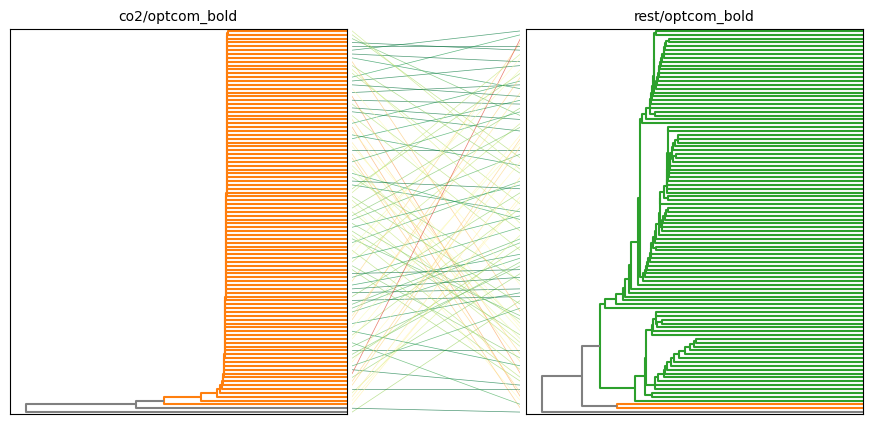

In [10]:
mv_table = hierarchy_metrics[hierarchy_metrics.backbone == 'mp_validated']
most_div = mv_table.loc[mv_table['bakers_gamma'].idxmin()]
proc = most_div['processing']
print(f"Most divergent processing (lowest Baker's γ on mp_validated): {proc}")
print(f"  cophenetic r = {most_div['cophenetic_r']:.3f}, "
      f"Baker's γ = {most_div['bakers_gamma']:.3f}, "
      f"Δlog τ* = {most_div['delta_log_tau_star']:+.3f}")
co2_div = globals_by_backbone['mp_validated'][('co2', proc)]
rest_div = globals_by_backbone['mp_validated'][('rest', proc)]
fig = plot_tanglegram(co2_div, rest_div,
                      labels=(f'co2/{proc}', f'rest/{proc}'),
                      figsize=(11, 5))
plt.show()


### 5.5 Cross-processing — fixed contrast

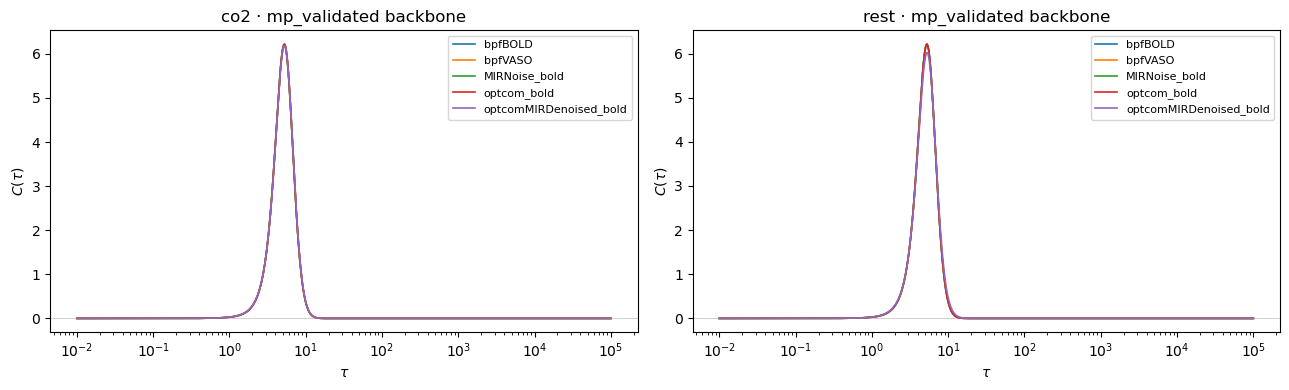

In [11]:
def _multi_processing_overlay(contrast, backbone='mp_validated', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.0, 3.5))
    else:
        fig = ax.get_figure()
    palette = plt.get_cmap('tab10')
    for k, processing in enumerate(PROCESSING_VARIANTS):
        res = globals_by_backbone[backbone].get((contrast, processing))
        if res is None or res.error is not None:
            continue
        ax.semilogx(res.time_grid_broad, res.specific_heat,
                    color=palette(k), linewidth=1.2, label=processing)
    ax.axhline(0, color='grey', linewidth=0.5, alpha=0.5)
    ax.set_xlabel(r'$\tau$')
    ax.set_ylabel(r'$C(\tau)$')
    ax.set_title(f'{contrast} · {backbone} backbone')
    ax.legend(fontsize=8, loc='best')
    return fig, ax


fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
_multi_processing_overlay('co2', ax=axes[0])
_multi_processing_overlay('rest', ax=axes[1])
plt.tight_layout()
plt.show()


## 6 · Per-band and per-patient sanity checks

§5 worked on the 10 globally aggregated matrices. Per-band aggregates
(3 IMF bands × 5 processing × 2 contrasts) and the 12-matrix patient
sample (2 subjects × 3 bands × 2 contrasts × `bpfBOLD`) let us check
that the headline finding survives at finer aggregation levels.


In [12]:
# Quick band-summary table: τ* shift and Δlog τ* across (band, processing) for each backbone

bands_df = manifests['bands'].copy()
bands_df['key'] = bands_df.apply(
    lambda r: f"{r.backbone}|{r.band}|{r.processing}", axis=1
)
pivot = bands_df.pivot_table(
    index=['backbone', 'band', 'processing'],
    columns='contrast',
    values='tau_star',
).reset_index()
if 'co2' in pivot.columns and 'rest' in pivot.columns:
    pivot['delta_log_tau_star'] = np.log10(pivot['co2']) - np.log10(pivot['rest'])
print('Band-level τ* CO2 vs rest:')
print(pivot.to_string(index=False, float_format='{:.3g}'.format))


Band-level τ* CO2 vs rest:
    backbone  band             processing  co2  rest  delta_log_tau_star
mp_validated    s4          MIRNoise_bold 5.28  5.28                   0
mp_validated    s4                bpfBOLD 5.28  5.28                   0
mp_validated    s4                bpfVASO 5.28  5.28                   0
mp_validated    s4 optcomMIRDenoised_bold 5.28  5.28                   0
mp_validated    s4            optcom_bold 5.28  5.28                   0
mp_validated    s5          MIRNoise_bold 5.28  5.28                   0
mp_validated    s5                bpfBOLD 5.28  5.28                   0
mp_validated    s5                bpfVASO 5.14  5.28             -0.0117
mp_validated    s5 optcomMIRDenoised_bold 5.28  5.28                   0
mp_validated    s5            optcom_bold 5.28  5.28                   0
mp_validated sstar          MIRNoise_bold 5.28  5.28                   0
mp_validated sstar                bpfBOLD 5.28  5.28                   0
mp_validated sstar      

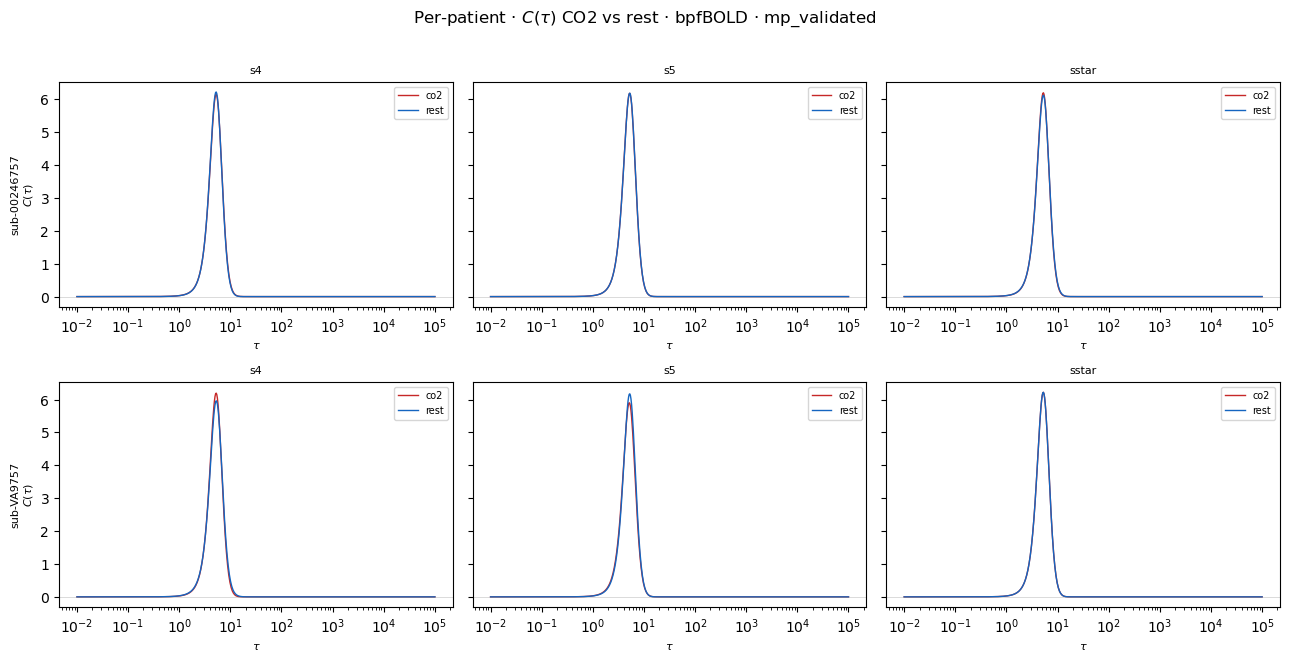

In [13]:
# Patient-sample C(τ) overlays per band, mp_validated backbone

def _load_patient(backbone):
    out = {}
    for path in (PATIENTS_DIR / backbone).rglob('*.pkl'):
        res = load_one(path)
        out[res.label] = res
    return out

patient_results = _load_patient('mp_validated')
SUBJECTS = ['sub-00246757', 'sub-VA9757']

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharey=True)
palette = {'co2': '#C62828', 'rest': '#1565C0'}
for r_idx, subject in enumerate(SUBJECTS):
    for c_idx, band in enumerate(BANDS):
        ax = axes[r_idx, c_idx]
        for contrast in CONTRASTS:
            label = f"patient/{subject}/{contrast}_bpfBOLD/{band}"
            res = patient_results.get(label)
            if res is None or res.error is not None:
                continue
            ax.semilogx(res.time_grid_broad, res.specific_heat,
                        color=palette[contrast], linewidth=1.0, label=contrast)
        ax.axhline(0, color='grey', linewidth=0.4, alpha=0.5)
        ax.set_xlabel(r'$\tau$', fontsize=8)
        if c_idx == 0:
            ax.set_ylabel(f'{subject}\n$C(\\tau)$', fontsize=8)
        ax.set_title(f'{band}', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
plt.suptitle('Per-patient · $C(\\tau)$ CO2 vs rest · bpfBOLD · mp_validated',
             y=1.01)
plt.tight_layout()
plt.show()


## Discussion — what does the spectrum say?

Headline reading order for the collaborators:

1. **§1 (specific heat across globals).** All 10 globals exhibit a single
   broad $C(\tau)$ peak around $\tau^\ast \approx 5$. The agreement
   between `mp_validated` and `percolation` backbones is the
   sensitivity check: the peak location and shape are not artefacts of
   the sparsifier.
2. **§5.1 — $\Delta\tau^\ast$ between CO2 and rest.** Read off
   $\log_{10}\tau^\ast(\mathrm{co2}) - \log_{10}\tau^\ast(\mathrm{rest})$
   from each overlay panel. A consistent positive shift across
   processing variants would indicate that hypercapnia **slows** the
   characteristic diffusion timescale of the connectome — the natural
   physical signature of vasoreactive coupling. A near-zero shift
   would mean the LRG view sees no contrast-driven scale change.
3. **§5.2 — RMI(τ) curve.** RMI is high (close to the entropy of either
   partition) when CO2 and rest produce essentially the *same* mesoscopic
   modules. An RMI dip at intermediate τ — between $\tau'$ and
   $\tau^\ast$ — is the diagnostic for **partition reorganisation**
   under hypercapnia. RMI is meaningful even when the two partitions
   have different cluster counts, which is why it replaces ARI here.
4. **§5.3 table — Baker's γ and cophenetic r.** Single-number summaries
   of full-hierarchy similarity at $\tau'$. Low Baker's γ (the
   rank-order metric) means the two dendrograms differ in *which leaves
   pair up first*, not just in the leaf labels. Pair this with the
   metastable-node Jaccard: if Baker's γ is low AND the metastable sets
   are mostly disjoint, hypercapnia is moving the **bridge nodes**, not
   just the cluster boundaries.
5. **§5.4 — tanglegram** of the most-divergent processing variant. Read
   the red lines: they're leaves whose vertical position differs most
   between the two dendrograms. Those leaves are the loci of contrast
   effect.

### Sensitivity caveats

- **Disparity α = 0.05 fails on dense correlation matrices.** With
  near-uniform per-node strength, the per-edge p-value
  $(1-w/s)^{k-1}$ is too smooth to discriminate signal from baseline.
  We replaced it with `percolation` as the second backbone — keeping
  disparity in the library for non-dense inputs.
- **High metastable-node counts (~100/100)** are expected with strict
  set-equality across τ: any small reshuffling between adjacent
  partitions flags every node as having changed its membership set.
  Reading `n_switches` rather than the bare metastable flag is the
  discriminating signal.
- **Two acquisition lengths** in this batch: $T = 442$ for
  `bpfBOLD`/`bpfVASO` and $T = 597$ for the `optcom_*`/`MIRNoise_bold`
  family. The per-variant $\gamma$ is propagated through MP denoise
  correctly.

### Follow-up if the result is flat

If §5.1 shows no $\tau^\ast$ shift, §5.2 no RMI dip, and §5.3 high
cophenetic $r$ and Baker's γ across every variant, the conclusion is
that **on these globally aggregated matrices the modular skeleton is
robust to hypercapnia**. Next probe: (a) re-run on per-patient matrices
with the full processing × band sweep, (b) signed-Laplacian LRG
($\bar L = |D| - A$) on the *unsparsified* MP-cleaned matrix to see if
the negative-tail information carries contrast signal, or (c)
eigenmode-level comparison — project onto the top signal eigenvectors
of CO2 and rest separately and compare loadings.
